# 1. Data Loading & Merging


In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load all three datasets
transfers = pd.read_csv('data/transfers.csv')
clubs = pd.read_csv('data/clubs.csv')
competitions = pd.read_csv('data/competitions.csv')

print(f"transfers.csv:    {transfers.shape[0]} rows, {transfers.shape[1]} columns")
print(f"clubs.csv:        {clubs.shape[0]} rows, {clubs.shape[1]} columns")
print(f"competitions.csv: {competitions.shape[0]} rows, {competitions.shape[1]} columns")

# Left-join club -> competition -> country so every transfer keeps its row
# even if a club/competition can't be matched (those become NaN, handled later)
df = transfers.merge(
    clubs[['club_id', 'domestic_competition_id']],
    left_on='to_club_id', right_on='club_id', how='left'
).drop(columns='club_id')

df = df.merge(
    competitions[['competition_id', 'country_name']],
    left_on='domestic_competition_id', right_on='competition_id', how='left'
).drop(columns='competition_id')

print(f"\nMerged dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn types:\n{df.dtypes}")
df.head(10)


transfers.csv:    100214 rows, 10 columns
clubs.csv:        451 rows, 17 columns
competitions.csv: 44 rows, 11 columns

Merged dataset: 100214 rows, 12 columns

Column types:
player_id                    int64
transfer_date               object
transfer_season             object
from_club_id                 int64
to_club_id                   int64
from_club_name              object
to_club_name                object
transfer_fee               float64
market_value_in_eur        float64
player_name                 object
domestic_competition_id     object
country_name                object
dtype: object


,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name,domestic_competition_id,country_name
0,467994,2030-06-30,25/26,5621,749,Reggiana,FC Empoli,0.0,700000.0,Luca Belardinelli,IT1,Italy
1,1077560,2027-06-30,26/27,3060,683,Atromitos,Olympiacos,0.0,1000000.0,Stavros Pnevmonidis,GR1,Greece
2,739277,2027-05-30,26/27,42055,589,Genclik Gücü,Antalyaspor,0.0,NaN,Yannick Nkurunziza,TR1,Turkey
3,1043003,2027-01-27,26/27,114,405,Besiktas,Aston Villa,0.0,5000000.0,Yasin Özcan,GB1,England
4,282727,2026-12-31,25/26,49283,605,FC Juárez,Aris Saloniki,0.0,6000000.0,Monchu,GR1,Greece
5,371996,2026-12-31,26/27,6600,2410,Internacional,CSKA Moscow,0.0,3000000.0,Alerrandro,RU1,Russia
6,401533,2026-12-31,26/27,2029,2423,Ceará SC,Santa Clara,0.0,1500000.0,Matheusinho,PO1,Portugal
7,462977,2026-12-31,26/27,605,978,Aris Saloniki,Vasco da Gama,0.0,3500000.0,Benjamín Garré,NaN,NaN
8,468256,2026-12-31,26/27,2035,16655,Avaí FC,Atlético-MG B,0.0,700000.0,Daniel Penha,NaN,NaN
9,541914,2026-12-31,26/27,713,1124,BATE Borisov,Fakel Voronezh,0.0,225000.0,Anton Kovalev,RU1,Russia


# 2. Data Exploration


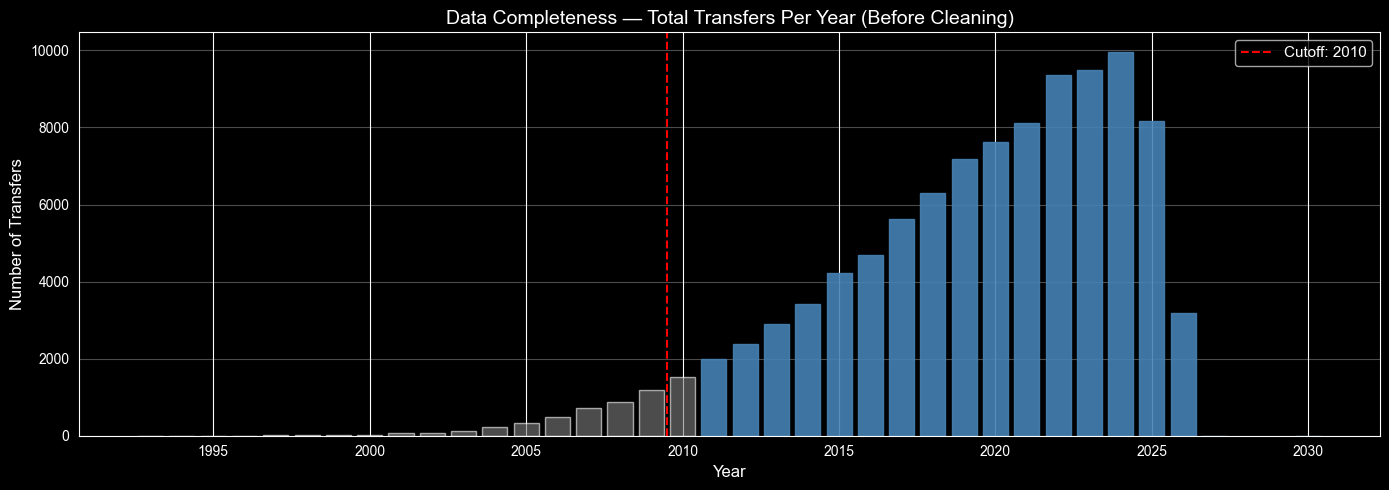

In [204]:
# Data completeness — transfers per year (before cleaning)
# Plotting total transfers per year reveals a drop-off before 2010.

df['transfer_date'] = pd.to_datetime(df['transfer_date'])
counts_per_year = df.groupby(df['transfer_date'].dt.year).size()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(counts_per_year.index, counts_per_year.values, color='grey', alpha=0.6)

for bar in bars:
    if bar.get_x() >= 2010:
        bar.set_color('steelblue')
        bar.set_alpha(0.9)

ax.axvline(x=2009.5, color='red', linestyle='--', linewidth=1.5, label='Cutoff: 2010')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Transfers', fontsize=12)
ax.set_title('Data Completeness — Total Transfers Per Year (Before Cleaning)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [205]:
# Null value analysis and descriptive statistics
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)

null_summary = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
print("Null value analysis:")
print(null_summary[null_summary['Null Count'] > 0])
print(f"\nTotal rows: {len(df)}")

# Descriptive statistics for numeric columns to understand distributions before cleaning
print("\n=== transfer_fee statistics ===")
print(df['transfer_fee'].describe())
print(f"Std Dev:  {df['transfer_fee'].std():,.2f}")
print(f"Variance: {df['transfer_fee'].var():,.2f}")
print(f"Median:   {df['transfer_fee'].median():,.2f}")

print("\n=== market_value_in_eur statistics ===")
print(df['market_value_in_eur'].describe())
print(f"Std Dev:  {df['market_value_in_eur'].std():,.2f}")
print(f"Variance: {df['market_value_in_eur'].var():,.2f}")
print(f"Median:   {df['market_value_in_eur'].median():,.2f}")

Null value analysis:
                         Null Count  Null %
transfer_fee                  34368   34.29
market_value_in_eur           38400   38.32
domestic_competition_id       55723   55.60
country_name                  55723   55.60

Total rows: 100214

=== transfer_fee statistics ===
count    6.584600e+04
mean     1.077348e+06
std      5.215225e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.800000e+08
Name: transfer_fee, dtype: float64
Std Dev:  5,215,225.43
Variance: 27,198,576,325,575.96
Median:   0.00

=== market_value_in_eur statistics ===
count    6.181400e+04
mean     2.429635e+06
std      5.803065e+06
min      1.000000e+04
25%      2.000000e+05
50%      6.000000e+05
75%      2.000000e+06
max      1.800000e+08
Name: market_value_in_eur, dtype: float64
Std Dev:  5,803,064.69
Variance: 33,675,559,791,420.36
Median:   600,000.00


# 3. Data Cleaning & Preparation


In [206]:
print(f"Rows before cleaning: {len(df)}")

# Filter to 2010 – summer 2025
cutoff_start = pd.Timestamp('2010-01-01')
cutoff_end = pd.Timestamp('2025-08-31')
before_2010 = (df['transfer_date'] < cutoff_start).sum()
after_summer_2025 = (df['transfer_date'] > cutoff_end).sum()
df = df[(df['transfer_date'] >= cutoff_start) & (df['transfer_date'] <= cutoff_end)]
print(f"Removed {before_2010} transfers before 2010 (incomplete source data)")
print(f"Removed {after_summer_2025} transfers after summer 2025 (cutoff: {cutoff_end.date()})")

# Fill null transfer fees with 0 (free transfers)
null_fees = df['transfer_fee'].isnull().sum()
df['transfer_fee'] = df['transfer_fee'].fillna(0)
print(f"Filled {null_fees} null transfer fees with 0")

# market_value_in_eur nulls kept as-is (not imputed)
null_mv = df['market_value_in_eur'].isnull().sum()
print(f"market_value_in_eur has {null_mv} nulls ({null_mv/len(df)*100:.1f}%) - kept as-is")

# Remove transfers without country mapping
no_country = df['country_name'].isnull().sum()
total_before = len(df)
df = df[df['country_name'].notna()]
print(f"Removed {no_country} transfers without country mapping ({no_country/total_before*100:.1f}%)")

# Remove self-transfers
self_transfers = (df['from_club_id'] == df['to_club_id']).sum()
df = df[df['from_club_id'] != df['to_club_id']]
print(f"Removed {self_transfers} self-transfers")

# Check for duplicate rows
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")
if dupes > 0:
    df = df.drop_duplicates()
    print(f"Removed {dupes} duplicates")

# Extract year for time-series analysis
df['year'] = df['transfer_date'].dt.year

print(f"\nRows after cleaning: {len(df)}")

Rows before cleaning: 100214
Removed 4144 transfers before 2010 (incomplete source data)
Removed 4109 transfers after summer 2025 (cutoff: 2025-08-31)
Filled 31475 null transfer fees with 0
market_value_in_eur has 34596 nulls (37.6%) - kept as-is
Removed 50978 transfers without country mapping (55.4%)
Removed 0 self-transfers
Duplicate rows found: 0

Rows after cleaning: 40983


# 4. Outlier Analysis


Paid transfers: 8780
Q1: €0.80M | Q3: €8.00M | IQR: €7.20M
Upper outlier bound (Q3 + 1.5*IQR): €18.80M
Outliers (above bound): 897 (10.2%)

Top 10 highest transfer fees:
      player_name from_club_name to_club_name  transfer_fee transfer_date
    Kylian Mbappé         Monaco          PSG   180000000.0    2018-07-01
  Ousmane Dembélé       Dortmund    Barcelona   148000000.0    2017-08-25
Philippe Coutinho      Liverpool    Barcelona   135000000.0    2018-01-08
       João Félix        Benfica     Atlético   127200000.0    2019-07-03
  Jude Bellingham       Dortmund  Real Madrid   127000000.0    2023-07-01
    Florian Wirtz     Leverkusen    Liverpool   125000000.0    2025-07-01
   Enzo Fernández        Benfica      Chelsea   121000000.0    2023-01-31
Antoine Griezmann       Atlético    Barcelona   120000000.0    2019-07-14
    Jack Grealish    Aston Villa     Man City   117500000.0    2021-08-05
      Declan Rice       West Ham      Arsenal   116600000.0    2023-07-15


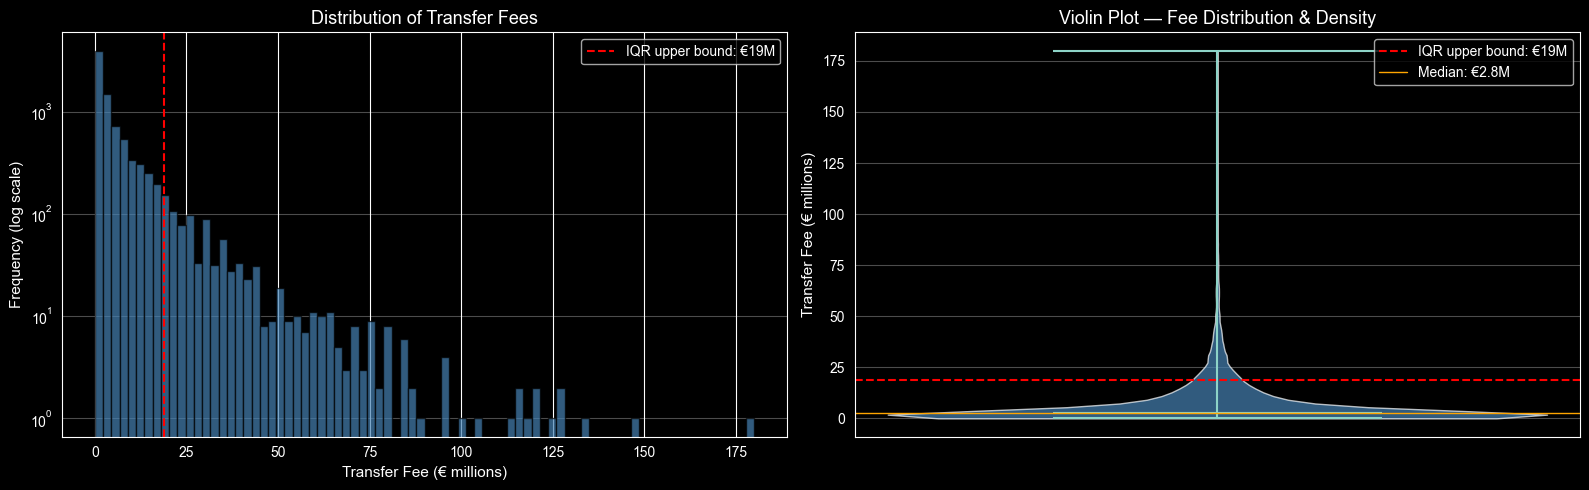

In [207]:
# Only consider paid transfers for outlier analysis
paid = df[df['transfer_fee'] > 0]['transfer_fee']

Q1 = paid.quantile(0.25)
Q3 = paid.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = paid[paid > upper_bound]

print(f"Paid transfers: {len(paid)}")
print(f"Q1: €{Q1/1e6:.2f}M | Q3: €{Q3/1e6:.2f}M | IQR: €{IQR/1e6:.2f}M")
print(f"Upper outlier bound (Q3 + 1.5*IQR): €{upper_bound/1e6:.2f}M")
print(f"Outliers (above bound): {len(outliers)} ({len(outliers)/len(paid)*100:.1f}%)")
print(f"\nTop 10 highest transfer fees:")
print(df.nlargest(10, 'transfer_fee')[['player_name', 'from_club_name', 'to_club_name', 'transfer_fee', 'transfer_date']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Histogram with IQR bound
axes[0].hist(paid / 1e6, bins=80, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(upper_bound / 1e6, color='red', linestyle='--', linewidth=1.5,
                label=f'IQR upper bound: €{upper_bound/1e6:.0f}M')
axes[0].set_xlabel('Transfer Fee (€ millions)', fontsize=11)
axes[0].set_ylabel('Frequency (log scale)', fontsize=11)
axes[0].set_title('Distribution of Transfer Fees', fontsize=13)
axes[0].set_yscale('log')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Right: Violin plot
import matplotlib.patches as mpatches
vp = axes[1].violinplot(paid / 1e6, positions=[0], showmedians=True, showextrema=True)
vp['bodies'][0].set_facecolor('steelblue')
vp['bodies'][0].set_alpha(0.7)
axes[1].axhline(upper_bound / 1e6, color='red', linestyle='--', linewidth=1.5,
                label=f'IQR upper bound: €{upper_bound/1e6:.0f}M')
axes[1].axhline(paid.median() / 1e6, color='orange', linestyle='-', linewidth=1,
                label=f'Median: €{paid.median()/1e6:.1f}M')
axes[1].set_ylabel('Transfer Fee (€ millions)', fontsize=11)
axes[1].set_title('Violin Plot — Fee Distribution & Density', fontsize=13)
axes[1].set_xticks([])
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# 5. Exploratory Data Analysis

With the cleaned dataset, we now explore transfer spending trends over time and across countries. The subset `df_paid` contains only paid transfers (fee > 0) and forms the basis for all visualisations. The central question is: **How have football transfer fees evolved, and which countries drive the escalation?**

In [208]:
# Create analysis-ready subset: only paid transfers (fee > 0)
df_paid = df[df['transfer_fee'] > 0].copy()

print(f"Total transfers after cleaning: {len(df)}")
print(f"Paid transfers (fee > 0):       {len(df_paid)}")

print(f"\nDescriptive statistics for transfer_fee (paid only):")
print(f"  Mean:     €{df_paid['transfer_fee'].mean()/1e6:.2f}M")
print(f"  Median:   €{df_paid['transfer_fee'].median()/1e6:.2f}M")
print(f"  Std Dev:  €{df_paid['transfer_fee'].std()/1e6:.2f}M")
print(f"  Variance: {df_paid['transfer_fee'].var():.2e}")
print(f"  Min:      €{df_paid['transfer_fee'].min()/1e6:.2f}M")
print(f"  Max:      €{df_paid['transfer_fee'].max()/1e6:.2f}M")

Total transfers after cleaning: 40983
Paid transfers (fee > 0):       8780

Descriptive statistics for transfer_fee (paid only):
  Mean:     €7.16M
  Median:   €2.75M
  Std Dev:  €12.00M
  Variance: 1.44e+14
  Min:      €0.00M
  Max:      €180.00M


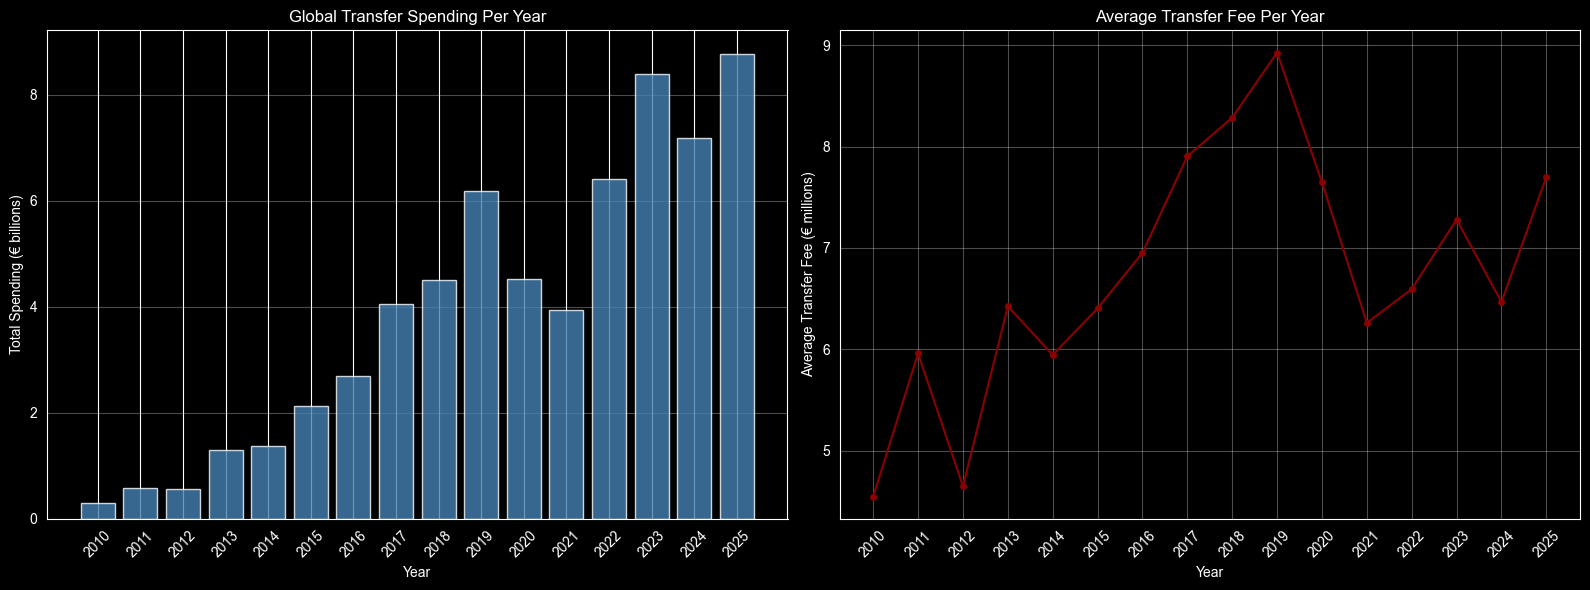

In [209]:
# Global transfer spending per year
global_spending = df_paid.groupby('year')['transfer_fee'].agg(['sum', 'mean', 'count']).reset_index()
global_spending.columns = ['year', 'total_spending', 'avg_fee', 'num_transfers']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total spending over time
axes[0].bar(global_spending['year'], global_spending['total_spending'] / 1e9, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Spending (€ billions)')
axes[0].set_title('Global Transfer Spending Per Year')
axes[0].set_xticks(global_spending['year'])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Average fee over time
axes[1].plot(global_spending['year'], global_spending['avg_fee'] / 1e6, marker='o', markersize=4, color='darkred')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Transfer Fee (€ millions)')
axes[1].set_title('Average Transfer Fee Per Year')
axes[1].set_xticks(global_spending['year'])
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

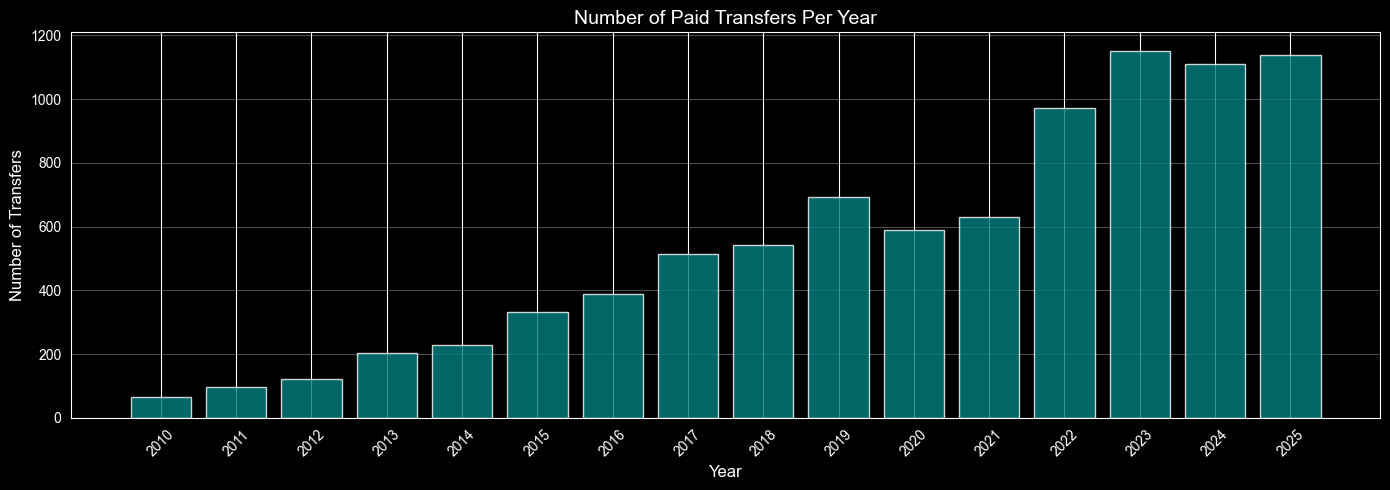

Total paid transfers in dataset: 8780
Peak year: 2023 with 1152 transfers


In [210]:
# Number of paid transfers per year
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(global_spending['year'], global_spending['num_transfers'], color='teal', alpha=0.8)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Transfers', fontsize=12)
ax.set_title('Number of Paid Transfers Per Year', fontsize=14)
ax.set_xticks(global_spending['year'])
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total paid transfers in dataset: {global_spending['num_transfers'].sum()}")
print(f"Peak year: {global_spending.loc[global_spending['num_transfers'].idxmax(), 'year']} "
      f"with {global_spending['num_transfers'].max()} transfers")

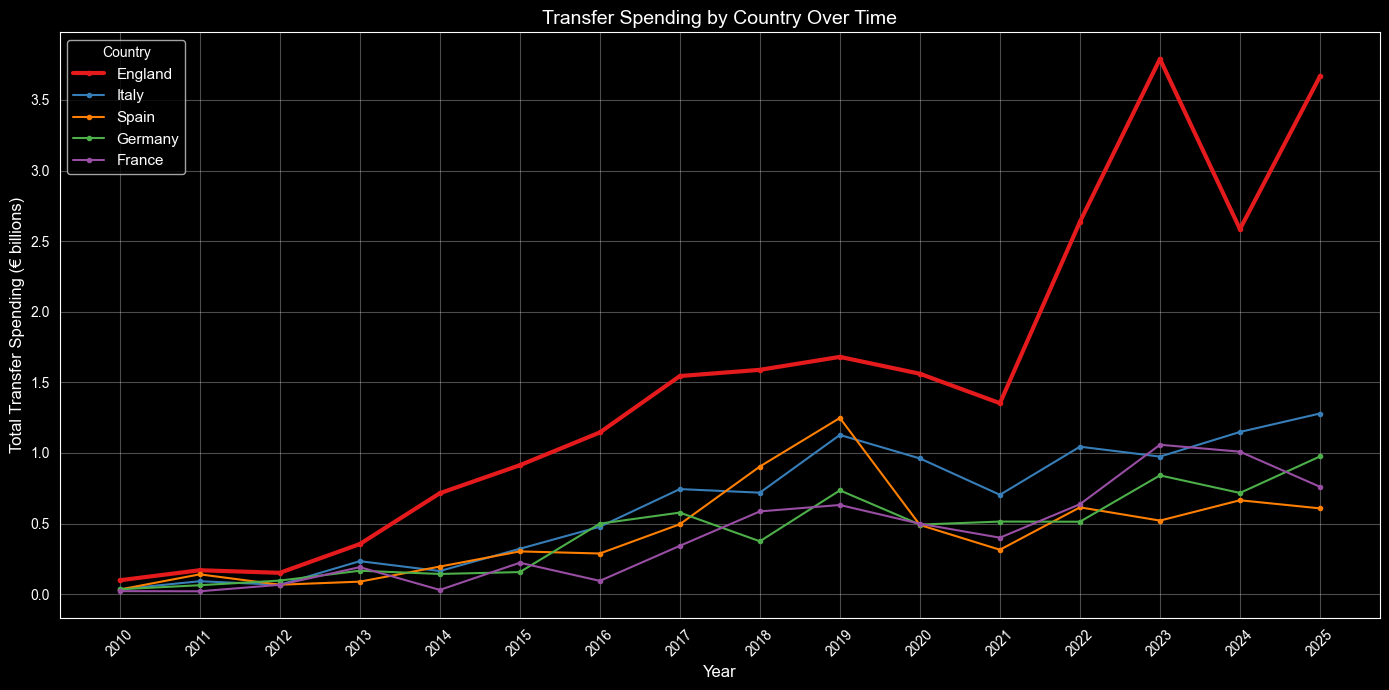

In [211]:
# Spending by country — Top 5 leagues over time
spending_by_country = df_paid.groupby(['year', 'country_name'])['transfer_fee'].sum().reset_index()

top_countries = (
    spending_by_country.groupby('country_name')['transfer_fee'].sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

fig, ax = plt.subplots(figsize=(14, 7))

colors = {'England': '#e41a1c', 'Spain': '#ff7f00', 'Italy': '#377eb8', 'Germany': '#4daf4a', 'France': '#984ea3'}

for country in top_countries:
    data = spending_by_country[spending_by_country['country_name'] == country]
    color = colors.get(country, 'grey')
    linewidth = 3 if country == 'England' else 1.5
    ax.plot(data['year'], data['transfer_fee'] / 1e9, marker='o', markersize=3,
            label=country, color=color, linewidth=linewidth)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Transfer Spending (€ billions)', fontsize=12)
ax.set_title('Transfer Spending by Country Over Time', fontsize=14)
ax.set_xticks(sorted(spending_by_country['year'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Country', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

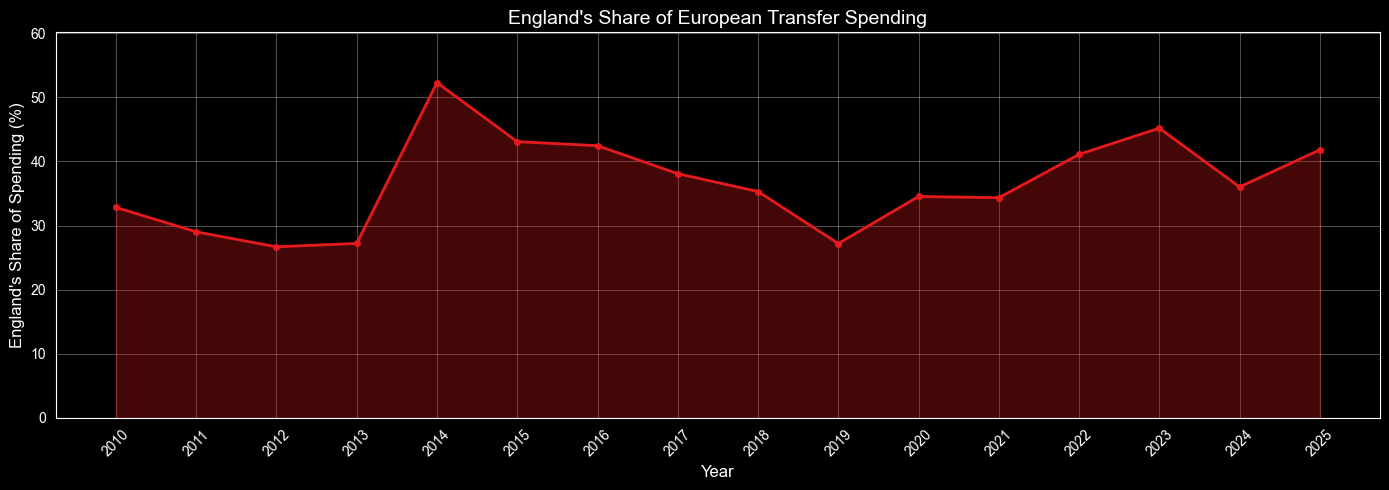

In [212]:
# England's share of global spending over time
england_spending = spending_by_country[spending_by_country['country_name'] == 'England'].set_index('year')['transfer_fee']
total_spending = spending_by_country.groupby('year')['transfer_fee'].sum()

share = (england_spending / total_spending * 100).dropna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(share.index, share.values, alpha=0.3, color='#e41a1c')
ax.plot(share.index, share.values, color='#e41a1c', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel("England's Share of Spending (%)", fontsize=12)
ax.set_title("England's Share of European Transfer Spending", fontsize=14)
ax.set_xticks(share.index)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, max(share.values) * 1.15)

plt.tight_layout()
plt.show()


# 6. Machine Learning — Predicting Transfer Fees


In [213]:
# Feature Engineering & Preparation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use paid transfers with known market value
df_ml = df_paid.dropna(subset=['market_value_in_eur']).copy()
print(f"ML dataset size: {len(df_ml)} rows (after dropping null market values)")

# Create binary country flags for the model
df_ml['is_england'] = (df_ml['country_name'] == 'England').astype(int)
for country in ['Spain', 'Italy', 'Germany', 'France']:
    df_ml[f'is_{country.lower()}'] = (df_ml['country_name'] == country).astype(int)

feature_cols = ['year', 'market_value_in_eur', 'is_england', 'is_spain', 'is_italy', 'is_germany', 'is_france']

X = df_ml[feature_cols]
y = df_ml['transfer_fee']

print(f"\nFeatures: {feature_cols}")
print(f"Target: transfer_fee")
print(f"\nFeature statistics:")
print(X.describe().round(2))

ML dataset size: 8619 rows (after dropping null market values)

Features: ['year', 'market_value_in_eur', 'is_england', 'is_spain', 'is_italy', 'is_germany', 'is_france']
Target: transfer_fee

Feature statistics:
          year  market_value_in_eur  is_england  is_spain  is_italy  \
count  8619.00         8.619000e+03     8619.00   8619.00   8619.00   
mean   2020.52         6.461371e+06        0.16      0.09      0.15   
std       3.70         1.057166e+07        0.37      0.28      0.36   
min    2010.00         1.000000e+04        0.00      0.00      0.00   
25%    2018.00         9.000000e+05        0.00      0.00      0.00   
50%    2022.00         2.500000e+06        0.00      0.00      0.00   
75%    2024.00         7.500000e+06        0.00      0.00      0.00   
max    2025.00         1.500000e+08        1.00      1.00      1.00   

       is_germany  is_france  
count     8619.00     8619.0  
mean         0.11        0.1  
std          0.32        0.3  
min          0.00      

In [214]:
# Train/Test Split (Hold-Out approach — 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {len(X_train)} samples")
print(f"Test set:     {len(X_test)} samples")

# --- Model 1: Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr_train = lr.predict(X_train)
y_pred_lr_test = lr.predict(X_test)

# --- Model 2: Random Forest ---
# max_depth=7 and min_samples_leaf=10 to prevent overfitting
rf = RandomForestRegressor(n_estimators=100, max_depth=7, min_samples_leaf=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

# --- Comparison table ---
results = pd.DataFrame({
    'Metric': ['MAE (€M)', 'RMSE (€M)', 'R² Score'],
    'Linear Reg (Train)': [
        mean_absolute_error(y_train, y_pred_lr_train) / 1e6,
        np.sqrt(mean_squared_error(y_train, y_pred_lr_train)) / 1e6,
        r2_score(y_train, y_pred_lr_train)
    ],
    'Linear Reg (Test)': [
        mean_absolute_error(y_test, y_pred_lr_test) / 1e6,
        np.sqrt(mean_squared_error(y_test, y_pred_lr_test)) / 1e6,
        r2_score(y_test, y_pred_lr_test)
    ],
    'Random Forest (Train)': [
        mean_absolute_error(y_train, y_pred_rf_train) / 1e6,
        np.sqrt(mean_squared_error(y_train, y_pred_rf_train)) / 1e6,
        r2_score(y_train, y_pred_rf_train)
    ],
    'Random Forest (Test)': [
        mean_absolute_error(y_test, y_pred_rf_test) / 1e6,
        np.sqrt(mean_squared_error(y_test, y_pred_rf_test)) / 1e6,
        r2_score(y_test, y_pred_rf_test)
    ]
}).round(4)

print("\n=== Model Comparison (Hold-Out) ===")
print(results.to_string(index=False))

Training set: 6895 samples
Test set:     1724 samples

=== Model Comparison (Hold-Out) ===
   Metric  Linear Reg (Train)  Linear Reg (Test)  Random Forest (Train)  Random Forest (Test)
 MAE (€M)              2.8776             2.8642                 2.7178                2.8193
RMSE (€M)              5.4881             6.0674                 5.2074                5.8891
 R² Score              0.7901             0.7627                 0.8110                0.7764


In [215]:
# Cross-Validation (5-fold) — assessing generalisation
cv_scores_lr = cross_val_score(lr, X, y, cv=5, scoring='r2')
cv_scores_rf = cross_val_score(rf, X, y, cv=5, scoring='r2')

cv_mae_lr = -cross_val_score(lr, X, y, cv=5, scoring='neg_mean_absolute_error')
cv_mae_rf = -cross_val_score(rf, X, y, cv=5, scoring='neg_mean_absolute_error')

print("=== 5-Fold Cross-Validation Results ===\n")
print("Linear Regression:")
print(f"  R² per fold:  {np.round(cv_scores_lr, 4)}")
print(f"  R² mean ± std: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")
print(f"  MAE mean: €{cv_mae_lr.mean()/1e6:.2f}M ± €{cv_mae_lr.std()/1e6:.2f}M")

print("\nRandom Forest:")
print(f"  R² per fold:  {np.round(cv_scores_rf, 4)}")
print(f"  R² mean ± std: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")
print(f"  MAE mean: €{cv_mae_rf.mean()/1e6:.2f}M ± €{cv_mae_rf.std()/1e6:.2f}M")

=== 5-Fold Cross-Validation Results ===

Linear Regression:
  R² per fold:  [0.8391 0.8118 0.7363 0.7561 0.7404]
  R² mean ± std: 0.7767 ± 0.0412
  MAE mean: €2.96M ± €0.24M

Random Forest:
  R² per fold:  [0.8138 0.8066 0.7725 0.7364 0.7597]
  R² mean ± std: 0.7778 ± 0.0290
  MAE mean: €2.92M ± €0.22M


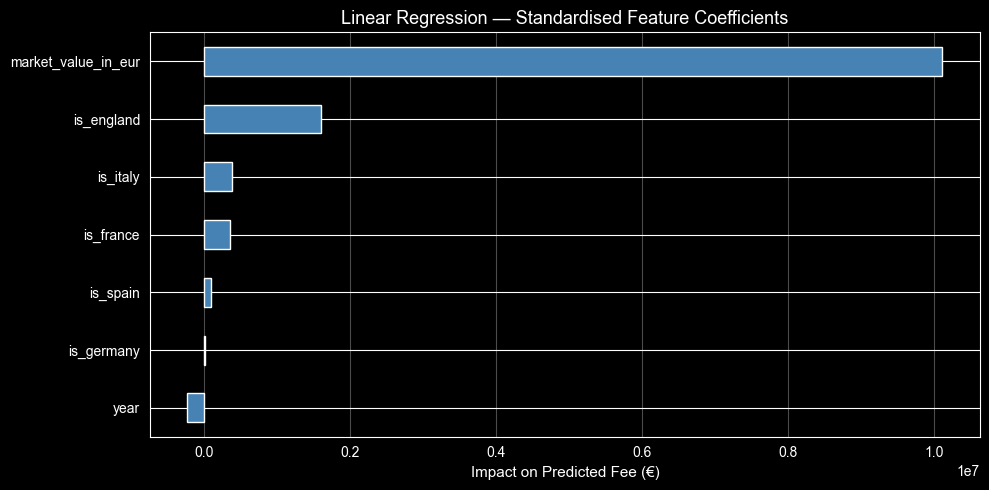

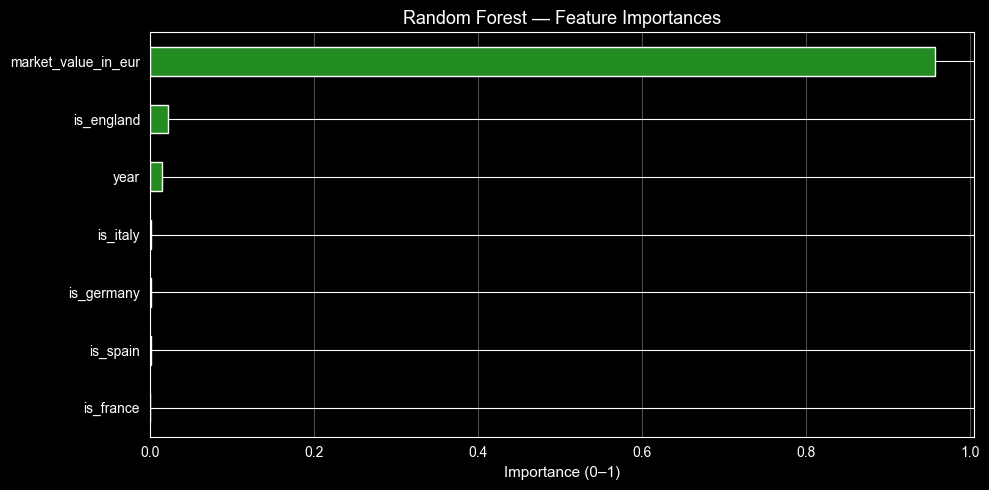

In [216]:
# Feature Importance — What drives transfer fees?

# Linear Regression: Standardised coefficients (coefficient × std of feature)
# This shows the actual impact of each feature on the predicted fee
scaled_coefs = lr.coef_ * X_train.std().values
scaled_coefs_series = pd.Series(scaled_coefs, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
scaled_coefs_series.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Impact on Predicted Fee (€)', fontsize=11)
ax.set_title('Linear Regression — Standardised Feature Coefficients', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Random Forest: Importances show how much each feature contributes to prediction accuracy
fig, ax = plt.subplots(figsize=(10, 5))
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind='barh', ax=ax, color='forestgreen')
ax.set_xlabel('Importance (0–1)', fontsize=11)
ax.set_title('Random Forest — Feature Importances', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


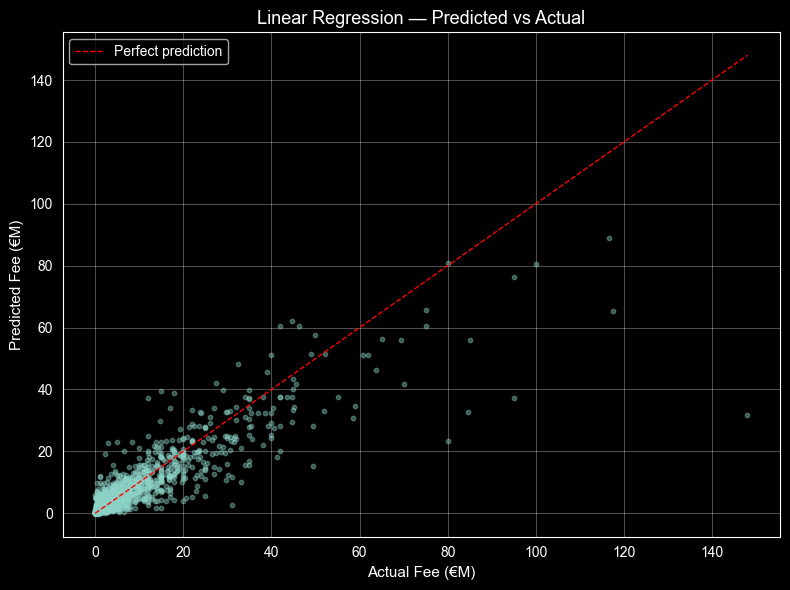

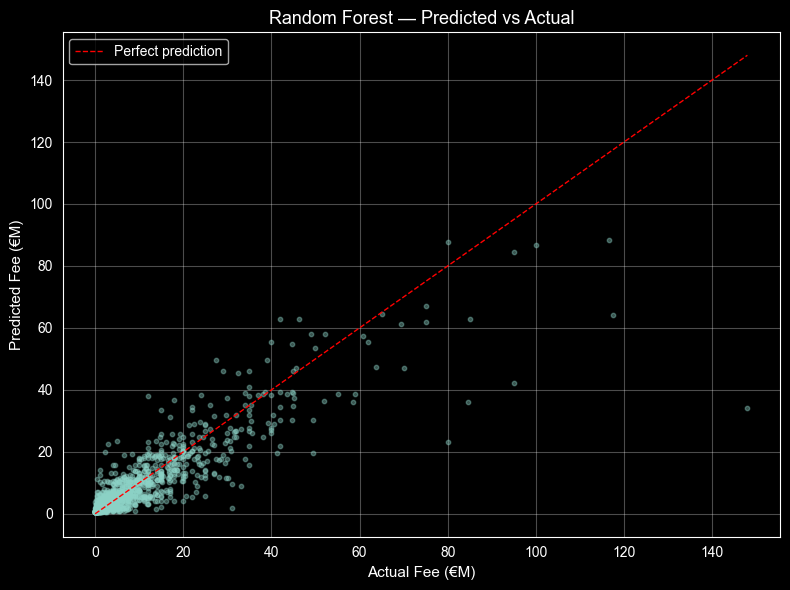

In [217]:
# Predicted vs Actual — Visual assessment of model quality

# Linear Regression
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test / 1e6, y_pred_lr_test / 1e6, alpha=0.4, s=10)
max_val = max(y_test.max(), max(y_pred_lr_test)) / 1e6
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual Fee (€M)', fontsize=11)
ax.set_ylabel('Predicted Fee (€M)', fontsize=11)
ax.set_title('Linear Regression — Predicted vs Actual', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test / 1e6, y_pred_rf_test / 1e6, alpha=0.4, s=10)
max_val = max(y_test.max(), max(y_pred_rf_test)) / 1e6
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual Fee (€M)', fontsize=11)
ax.set_ylabel('Predicted Fee (€M)', fontsize=11)
ax.set_title('Random Forest — Predicted vs Actual', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [218]:
#  Model Evaluation Summary
print("=" * 70)
print("  MODEL EVALUATION SUMMARY")
print("=" * 70)

lr_train_r2 = r2_score(y_train, y_pred_lr_train)
lr_test_r2 = r2_score(y_test, y_pred_lr_test)
rf_train_r2 = r2_score(y_train, y_pred_rf_train)
rf_test_r2 = r2_score(y_test, y_pred_rf_test)

lr_test_mae = mean_absolute_error(y_test, y_pred_lr_test) / 1e6
rf_test_mae = mean_absolute_error(y_test, y_pred_rf_test) / 1e6

print(f"\n  Linear Regression:   R² = {lr_test_r2:.2f}   MAE = €{lr_test_mae:.2f}M")
print(f"  Random Forest:       R² = {rf_test_r2:.2f}   MAE = €{rf_test_mae:.2f}M")

print(f"\n  --- Overfitting Check (Train-Test R² Gap) ---")
print(f"  Linear Regression:   {lr_train_r2:.3f} (train) - {lr_test_r2:.3f} (test) = {lr_train_r2 - lr_test_r2:.3f} gap")
print(f"  Random Forest:       {rf_train_r2:.3f} (train) - {rf_test_r2:.3f} (test) = {rf_train_r2 - rf_test_r2:.3f} gap")

print(f"\n  --- 5-Fold Cross-Validation ---")
print(f"  Linear Regression:   R² = {cv_scores_lr.mean():.3f} ± {cv_scores_lr.std():.3f}")
print(f"  Random Forest:       R² = {cv_scores_rf.mean():.3f} ± {cv_scores_rf.std():.3f}")

print(f"\n  --- Hyperparameter Tuning ---")
print(f"  Initial RF (max_depth=15):           train-test gap = 0.175")
print(f"  Tuned RF (max_depth=7, leaf=10):     train-test gap = {rf_train_r2 - rf_test_r2:.3f}")

print(f"\n  --- Negative Predictions ---")
print(f"  Linear Regression:   {(y_pred_lr_test < 0).sum()} negative predictions (impossible)")
print(f"  Random Forest:       {(y_pred_rf_test < 0).sum()} negative predictions")

  MODEL EVALUATION SUMMARY

  Linear Regression:   R² = 0.76   MAE = €2.86M
  Random Forest:       R² = 0.78   MAE = €2.82M

  --- Overfitting Check (Train-Test R² Gap) ---
  Linear Regression:   0.790 (train) - 0.763 (test) = 0.027 gap
  Random Forest:       0.811 (train) - 0.776 (test) = 0.035 gap

  --- 5-Fold Cross-Validation ---
  Linear Regression:   R² = 0.777 ± 0.041
  Random Forest:       R² = 0.778 ± 0.029

  --- Hyperparameter Tuning ---
  Initial RF (max_depth=15):           train-test gap = 0.175
  Tuned RF (max_depth=7, leaf=10):     train-test gap = 0.035

  --- Negative Predictions ---
  Linear Regression:   8 negative predictions (impossible)
  Random Forest:       0 negative predictions
